In [23]:
import numpy as np
import pandas as pd

In [24]:
df = pd.DataFrame({
    "Soil_pH": [1.20, 1.80, 2.50, 2.90, 3.40, 3.80, 4.10, 4.50, 4.80, 5.00],
    "Rainfall_mm": [102, 108, 115, 121, 110, 118, 123, 125, 116, 105],
    "Plant_Grown": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
})

In [25]:
df

,Soil_pH,Rainfall_mm,Plant_Grown
0,1.2,102,0
1,1.8,108,0
2,2.5,115,0
3,2.9,121,0
4,3.4,110,1
5,3.8,118,1
6,4.1,123,1
7,4.5,125,1
8,4.8,116,1
9,5.0,105,1


In [26]:
df['pre1(log-odds)'] = np.log(6/4)
df

,Soil_pH,Rainfall_mm,Plant_Grown,pre1(log-odds)
0,1.2,102,0,0.405465
1,1.8,108,0,0.405465
2,2.5,115,0,0.405465
3,2.9,121,0,0.405465
4,3.4,110,1,0.405465
5,3.8,118,1,0.405465
6,4.1,123,1,0.405465
7,4.5,125,1,0.405465
8,4.8,116,1,0.405465
9,5.0,105,1,0.405465


In [27]:
df['pre1(probability)'] = 1/(1 + np.exp(-np.log(6/4)))
df

,Soil_pH,Rainfall_mm,Plant_Grown,pre1(log-odds),pre1(probability)
0,1.2,102,0,0.405465,0.6
1,1.8,108,0,0.405465,0.6
2,2.5,115,0,0.405465,0.6
3,2.9,121,0,0.405465,0.6
4,3.4,110,1,0.405465,0.6
5,3.8,118,1,0.405465,0.6
6,4.1,123,1,0.405465,0.6
7,4.5,125,1,0.405465,0.6
8,4.8,116,1,0.405465,0.6
9,5.0,105,1,0.405465,0.6


In [28]:
df['res1'] = df['Plant_Grown'] - df['pre1(probability)']
df

,Soil_pH,Rainfall_mm,Plant_Grown,pre1(log-odds),pre1(probability),res1
0,1.2,102,0,0.405465,0.6,-0.6
1,1.8,108,0,0.405465,0.6,-0.6
2,2.5,115,0,0.405465,0.6,-0.6
3,2.9,121,0,0.405465,0.6,-0.6
4,3.4,110,1,0.405465,0.6,0.4
5,3.8,118,1,0.405465,0.6,0.4
6,4.1,123,1,0.405465,0.6,0.4
7,4.5,125,1,0.405465,0.6,0.4
8,4.8,116,1,0.405465,0.6,0.4
9,5.0,105,1,0.405465,0.6,0.4


In [29]:
from sklearn.tree import DecisionTreeRegressor
reg1 = DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)
reg1.fit(df.iloc[:,0:2].values, df.iloc[:,-1].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_le

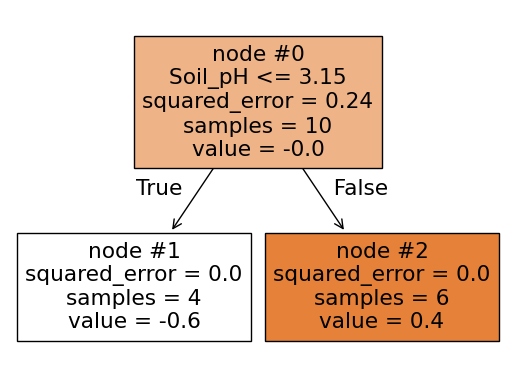

In [30]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plot_tree(reg1, feature_names=['Soil_pH','Rainfall_mm'],filled=True, node_ids=True)
plt.show()

In [31]:
df['leaf_entry1'] = reg1.apply(df.iloc[:,0:2])
df

C:\Users\Anshuman Tiwari\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,Soil_pH,Rainfall_mm,Plant_Grown,pre1(log-odds),pre1(probability),res1,leaf_entry1
0,1.2,102,0,0.405465,0.6,-0.6,1
1,1.8,108,0,0.405465,0.6,-0.6,1
2,2.5,115,0,0.405465,0.6,-0.6,1
3,2.9,121,0,0.405465,0.6,-0.6,1
4,3.4,110,1,0.405465,0.6,0.4,2
5,3.8,118,1,0.405465,0.6,0.4,2
6,4.1,123,1,0.405465,0.6,0.4,2
7,4.5,125,1,0.405465,0.6,0.4,2
8,4.8,116,1,0.405465,0.6,0.4,2
9,5.0,105,1,0.405465,0.6,0.4,2


In [32]:
def return_logs(leaf):
  temp_df = df[df['leaf_entry1'] == leaf]
  num = temp_df['res1'].sum()

  den = sum(temp_df['pre1(probability)'] * (1 - temp_df['pre1(probability)']))
  return round(num/den,2)

In [33]:
df['pre2(log-odds)'] = df['pre1(log-odds)'] + df['leaf_entry1'].apply(return_logs)

In [34]:
df['pre2(probability)'] = 1/(1+np.exp(-df['pre2(log-odds)']))
df

,Soil_pH,Rainfall_mm,Plant_Grown,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability)
0,1.2,102,0,0.405465,0.6,-0.6,1,-2.094535,0.109629
1,1.8,108,0,0.405465,0.6,-0.6,1,-2.094535,0.109629
2,2.5,115,0,0.405465,0.6,-0.6,1,-2.094535,0.109629
3,2.9,121,0,0.405465,0.6,-0.6,1,-2.094535,0.109629
4,3.4,110,1,0.405465,0.6,0.4,2,2.075465,0.888496
5,3.8,118,1,0.405465,0.6,0.4,2,2.075465,0.888496
6,4.1,123,1,0.405465,0.6,0.4,2,2.075465,0.888496
7,4.5,125,1,0.405465,0.6,0.4,2,2.075465,0.888496
8,4.8,116,1,0.405465,0.6,0.4,2,2.075465,0.888496
9,5.0,105,1,0.405465,0.6,0.4,2,2.075465,0.888496


In [35]:
df['res2'] = df['Plant_Grown'] - df['pre2(probability)']
df

,Soil_pH,Rainfall_mm,Plant_Grown,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2
0,1.2,102,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629
1,1.8,108,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629
2,2.5,115,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629
3,2.9,121,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629
4,3.4,110,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504
5,3.8,118,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504
6,4.1,123,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504
7,4.5,125,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504
8,4.8,116,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504
9,5.0,105,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504


In [36]:
reg2 = DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)
reg2.fit(df.iloc[:,0:2].values, df.iloc[:,-1].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_le

C:\Users\Anshuman Tiwari\AppData\Roaming\Python\Python314\site-packages\sklearn\tree\_export.py:683: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
C:\Users\Anshuman Tiwari\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


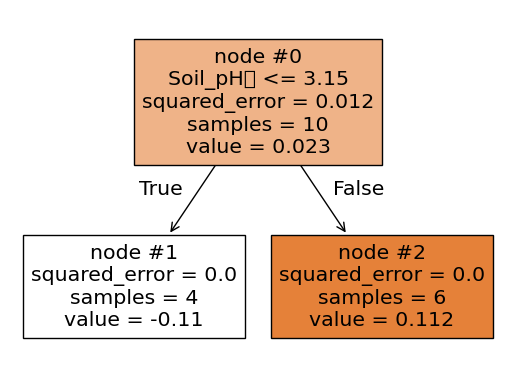

In [37]:
plot_tree(reg2, feature_names=['Soil_pH	','Rainfall_mm'],filled=True, node_ids=True)
plt.show()

In [38]:
df['leaf_entry2'] = reg2.apply(df.iloc[:,0:2])
df

C:\Users\Anshuman Tiwari\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,Soil_pH,Rainfall_mm,Plant_Grown,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2,leaf_entry2
0,1.2,102,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629,1
1,1.8,108,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629,1
2,2.5,115,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629,1
3,2.9,121,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629,1
4,3.4,110,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2
5,3.8,118,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2
6,4.1,123,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2
7,4.5,125,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2
8,4.8,116,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2
9,5.0,105,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2


In [39]:
def return_logs(leaf):
  num = df[df['leaf_entry2'] == leaf]['res2'].sum()
  den = sum(df[df['leaf_entry2'] == leaf]['pre2(probability)'] * (1 - df[df['leaf_entry2'] == leaf]['pre2(probability)']))
  return round(num/den,2)

In [40]:
df['pre3(log-odds)'] = df['pre1(log-odds)'] + df['pre2(log-odds)'] + df['leaf_entry2'].apply(return_logs)

In [41]:
df['pre3(probability)'] = 1/(1+np.exp(-df['pre3(log-odds)']))
df

,Soil_pH,Rainfall_mm,Plant_Grown,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2,leaf_entry2,pre3(log-odds),pre3(probability)
0,1.2,102,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629,1,-2.80907,0.056836
1,1.8,108,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629,1,-2.80907,0.056836
2,2.5,115,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629,1,-2.80907,0.056836
3,2.9,121,0,0.405465,0.6,-0.6,1,-2.094535,0.109629,-0.109629,1,-2.80907,0.056836
4,3.4,110,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2,3.61093,0.973685
5,3.8,118,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2,3.61093,0.973685
6,4.1,123,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2,3.61093,0.973685
7,4.5,125,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2,3.61093,0.973685
8,4.8,116,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2,3.61093,0.973685
9,5.0,105,1,0.405465,0.6,0.4,2,2.075465,0.888496,0.111504,2,3.61093,0.973685


In [42]:
df['res_final'] = df['Plant_Grown'] - df['pre3(probability)']
df[['res1','res2','res_final']]

,res1,res2,res_final
0,-0.6,-0.109629,-0.056836
1,-0.6,-0.109629,-0.056836
2,-0.6,-0.109629,-0.056836
3,-0.6,-0.109629,-0.056836
4,0.4,0.111504,0.026315
5,0.4,0.111504,0.026315
6,0.4,0.111504,0.026315
7,0.4,0.111504,0.026315
8,0.4,0.111504,0.026315
9,0.4,0.111504,0.026315
